# Revision: Thermodynamic Filter Bias and Extended BEP/ML Analysis

Objective: evaluate whether the `DeltaG_rxn < -4.1 kcal/mol` thermodynamic filter artificially induces the BEP relationship, and quantify how the filter-failed TS/IRC results affect BEP interpretation and descriptor-based ML behavior.

Primary reviewer-runnable inputs:
- `Data/TS/result_filter_extended.csv` and `Data/TS/result_filter_extended.xyz`: the already prepared thermodynamic-filter-failed TS set.
- Entries with `N_Index == 5` are excluded at the top of the notebook because Nu5 undergoes SF3 radical detachment rather than the target XAT transition state.
- `Data/TS/Borane_all.csv`: final curated 9237-reaction dataset.
- `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl`: precomputed descriptor maps used by `5_Modeling.ipynb`.

An optional `[RAW-GAUSSIAN/E:/work]` provenance cell below documents how the local `Data/TS` extended CSV/XYZ artifacts were originally generated from the historical E-drive calculation workspace. Reviewers do not need to run that cell.

CSV outputs are intentionally limited to:
- `Ignored/revision_thermo_filter_outputs/bep_summary.csv`
- `Ignored/revision_thermo_filter_outputs/ml_summary.csv`

Figures are still written to `Figure/`.



## Plan

1. Load the local filter-failed table from `Data/TS` and exclude `N_Index == 5` immediately.
2. Confirm that the matching extended XYZ file is present and has the expected number of structures.
3. Merge component metadata so the extended table can use the same descriptor pipeline as the final 9237-row set.
4. Refit BEP relationships for final-only, filter-failed-only, and final + filter-failed datasets.
5. Check descriptor coverage for all retained filter-failed rows.
6. Compare ML behavior in two ways:
   - train/evaluate within the augmented dataset and compare feature importance with the original dataset;
   - train on the original 9237 rows and test directly on the retained thermodynamically unfavorable rows.
7. Summarize reactant coverage and first-stage LB-B complexation status in memory for interpretation.



In [11]:
from __future__ import annotations

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

RANDOM_STATE = 0
HARTREE_TO_KCAL = 627.5

DATA_TS_DIR = Path("Data/TS")
CSV_DIR = Path("Data/csvs")
DESCRIPTOR_DIR = Path("Data/descriptor")
FIGURE_DIR = Path("Figure")
IGNORED_DIR = Path("Ignored")
OUTPUT_DIR = IGNORED_DIR / "revision_thermo_filter_outputs"

EXTENDED_SOURCE_CSV = DATA_TS_DIR / "result_filter_extended_raw_including_Nu5.csv"
EXTENDED_CSV = DATA_TS_DIR / "result_filter_extended.csv"
EXTENDED_XYZ = DATA_TS_DIR / "result_filter_extended.xyz"
EXTENDED_XYZ_SUMMARY = DATA_TS_DIR / "result_filter_extended_xyz_summary.csv"
FINAL_CSV = DATA_TS_DIR / "Borane_all.csv"

# Exclude Nu5 from the extended set: it follows SF3 radical detachment rather than target XAT.
EXCLUDED_N_INDEXES = [5]

FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_TS_DIR.mkdir(exist_ok=True)

# Set to True for quick local checks. Set to False for final CatBoost-style runs.
FAST_MODE = True
CATBOOST_ITERATIONS = 1000 if FAST_MODE else 10000
RF_TREES = 100 if FAST_MODE else 500
N_SPLITS = 5


## 1. Load Local Extended Set And Exclude Nu5

For reviewer-style reruns, start from the prepared files in `Data/TS`: `result_filter_extended.csv` and `result_filter_extended.xyz`. The raw E-drive Gaussian workspace was used only once to prepare these local artifacts and is not required for the BEP or ML analyses below.

If a raw local copy including Nu5 is intentionally placed at `Data/TS/result_filter_extended_raw_including_Nu5.csv`, the next cell will use it and remove `N_Index == 5`; otherwise it uses the already-filtered `Data/TS/result_filter_extended.csv`.


In [13]:
source_csv = EXTENDED_SOURCE_CSV if EXTENDED_SOURCE_CSV.exists() else EXTENDED_CSV
assert source_csv.exists(), source_csv

extended_source = pd.read_csv(source_csv)
for col in ["B_Index", "N_Index", "Cl_Index", "Conf_id"]:
    extended_source[col] = extended_source[col].astype(int)

excluded_by_nu = extended_source.loc[extended_source["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()
extended_raw = extended_source.loc[~extended_source["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()

print(f"Source CSV: {source_csv}")
print(f"Raw/source rows: {len(extended_source)}")
print(f"Excluded rows with N_Index in {EXCLUDED_N_INDEXES}: {len(excluded_by_nu)}")
print(f"Analysis extended rows: {len(extended_raw)}")

extended_raw.shape, extended_raw.head()


Source CSV: Data\TS\result_filter_extended.csv
Raw/source rows: 946
Excluded rows with N_Index in [5]: 0
Analysis extended rows: 946


((946, 9),
    B_Index  N_Index  Cl_Index  Conf_id         TS_G  deltaG(kcal/mol)  \
 0      388        1       492       12 -1349.533020          2.364608   
 1      388       33       492       10 -1520.331794          2.182257   
 2      388       71       492       10 -2436.856731         20.231855   
 3      388       75       492       10 -1827.841305         13.561844   
 4      388      141       480        0 -2000.912284         20.991506   
 
    deltaGa(kcal/mol)      B_Cl      C_Cl  
 0          11.530080  2.572357  1.858821  
 1          11.598377  2.573153  1.861774  
 2          25.834702  2.252840  1.989601  
 3          19.894047  2.348250  1.967186  
 4          24.649675  2.258242  2.008428  )

### Optional Provenance: Generate Local Extended CSV/XYZ From The Historical E-Drive Workspace

`[RAW-GAUSSIAN/E:/work]` This cell records the one-time preparation step used to create the local `Data/TS/result_filter_extended.csv` and `Data/TS/result_filter_extended.xyz` files from the historical raw Gaussian workspace. It is disabled by default and should be skipped by reviewers, because the manuscript/revision analyses below only need the prepared `Data/TS` files. The E-drive source has already been processed in our working copy; rerunning this cell is only for internal provenance if the raw workspace is restored.


In [ ]:
# [RAW-GAUSSIAN/E:/work] Optional one-time provenance/export cell.
# Reviewers should skip this cell: the BEP/ML analysis starts from Data/TS/result_filter_extended.csv
# and Data/TS/result_filter_extended.xyz, which were already prepared from the raw calculation workspace.

RUN_RAW_E_DRIVE_XYZ_EXPORT = False

if RUN_RAW_E_DRIVE_XYZ_EXPORT:
    from DFTStructureGenerator.logfile_process import Logfile

    RAW_EXTENDED_CSV = Path(r"E:/work/B_Cl_Nu/Sum/result_filter_extended.csv")
    RAW_TS_DIR = Path(r"E:/work/B_Cl_Nu/Sum/TS_needIRC")

    assert RAW_EXTENDED_CSV.exists(), RAW_EXTENDED_CSV
    assert RAW_TS_DIR.exists(), RAW_TS_DIR

    raw_e_df = pd.read_csv(RAW_EXTENDED_CSV)
    for col in ["B_Index", "N_Index", "Cl_Index", "Conf_id"]:
        raw_e_df[col] = raw_e_df[col].astype(int)

    retained_e_df = raw_e_df.loc[~raw_e_df["N_Index"].isin(EXCLUDED_N_INDEXES)].copy()
    retained_e_df.to_csv(EXTENDED_CSV, index=False)

    def candidate_ts_logs(row):
        b = int(row["B_Index"])
        n = int(row["N_Index"])
        cl = int(row["Cl_Index"])
        conf = int(row["Conf_id"])
        exact_names = [
            RAW_TS_DIR / f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}_{conf:04}.log",
            RAW_TS_DIR / f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}.log",
        ]
        globbed = sorted(RAW_TS_DIR.glob(f"B_{b:05}_Nu_{n:05}_Cl_{cl:05}*.log"))
        seen = set()
        for path in exact_names + globbed:
            if path not in seen:
                seen.add(path)
                yield path

    def read_ts_xyz(row):
        tried = []
        for log_path in candidate_ts_logs(row):
            tried.append(str(log_path))
            if not log_path.exists():
                continue
            log = Logfile(str(log_path), ignore_print=True)
            if log.running_positions is None or len(log.running_positions) == 0:
                continue
            return log_path, log.symbol_list, log.running_positions[-1]
        raise FileNotFoundError("No readable TS log found. Tried: " + "; ".join(tried))

    xyz_records = []
    with EXTENDED_XYZ.open("w", encoding="utf-8") as handle:
        for _, row in retained_e_df.iterrows():
            log_path, symbols, positions = read_ts_xyz(row)
            comment = (
                f"B_Index={int(row['B_Index'])}; "
                f"N_Index={int(row['N_Index'])}; "
                f"Cl_Index={int(row['Cl_Index'])}; "
                f"Conf_id={int(row['Conf_id'])}; "
                f"source={log_path.as_posix()}"
            )
            handle.write(f"{len(symbols)}\n{comment}\n")
            for symbol, xyz in zip(symbols, positions):
                x, y, z = map(float, xyz)
                handle.write(f"{symbol:<2} {x:16.8f} {y:16.8f} {z:16.8f}\n")
            xyz_records.append({
                "B_Index": int(row["B_Index"]),
                "N_Index": int(row["N_Index"]),
                "Cl_Index": int(row["Cl_Index"]),
                "Conf_id": int(row["Conf_id"]),
                "natoms": len(symbols),
                "source_log": log_path.as_posix(),
            })

    xyz_generation_summary = pd.DataFrame(xyz_records)
    print(f"Raw E-drive rows: {len(raw_e_df)}")
    print(f"Excluded Nu rows: {len(raw_e_df) - len(retained_e_df)}")
    print(f"Wrote local CSV: {EXTENDED_CSV} ({len(retained_e_df)} rows)")
    print(f"Wrote local XYZ: {EXTENDED_XYZ} ({len(xyz_generation_summary)} structures)")
    display(xyz_generation_summary.head())
else:
    print("Skipped raw E-drive export. Use the prepared Data/TS/result_filter_extended.csv and .xyz files for reviewer-runnable analysis.")


In [ ]:
def count_xyz_structures(path: Path):
    if not path.exists():
        return 0, pd.Series(dtype=int, name="natoms")
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    i = 0
    count = 0
    natoms = []
    while i < len(lines):
        n = int(lines[i])
        natoms.append(n)
        count += 1
        i += n + 2
    return count, pd.Series(natoms, name="natoms")

xyz_count, xyz_natoms = count_xyz_structures(EXTENDED_XYZ)
print(f"Existing XYZ: {EXTENDED_XYZ}")
print(f"XYZ structures: {xyz_count}")
print(xyz_natoms.describe())

if EXTENDED_XYZ_SUMMARY.exists():
    xyz_summary = pd.read_csv(EXTENDED_XYZ_SUMMARY)
    display(xyz_summary.head())

assert xyz_count == len(extended_raw), (
    f"XYZ structure count ({xyz_count}) does not match retained extended rows ({len(extended_raw)}). "
    "Regenerate Data/TS/result_filter_extended.xyz if this assertion fails."
)


## 2. Build Analysis Table Compatible With The Original Descriptor Pipeline

`result_filter_extended.csv` contains energies and TS geometry metadata, while descriptor construction also needs reactant/component metadata such as `B_smiles`, `N_smiles`, `Cl_smiles`, and `Cl_Atomid`. These are merged from the existing curated component tables.




In [16]:
final_df = pd.read_csv(FINAL_CSV)
bn_meta = pd.read_csv(CSV_DIR / "reactants_B_N.csv")
cl_meta = pd.read_csv(CSV_DIR / "reactants_Cl.csv")

bn_cols = [
    "B_smiles", "B_Index", "B_Atomid", "N_smiles", "N_Index", "N_Atomid",
    "conf_idxs_p", "deltaG_react",
]
cl_cols = ["Smiles", "Index", "Atomid", "conf_idxs_r"]

extended_df = (
    extended_raw
    .merge(bn_meta[bn_cols], on=["B_Index", "N_Index"], how="left")
    .merge(
        cl_meta[cl_cols].rename(columns={
            "Smiles": "Cl_smiles",
            "Index": "Cl_Index",
            "Atomid": "Cl_Atomid",
            "conf_idxs_r": "Cl_r_conf",
        }),
        on="Cl_Index",
        how="left",
    )
)
extended_df = extended_df.rename(columns={"conf_idxs_p": "B_N_Cl_conf", "Conf_id": "conf_idxs_ts"})
extended_df["G_energy"] = np.nan
extended_df["AAM"] = ""

ordered_cols = [
    "B_smiles", "B_Index", "B_Atomid", "N_smiles", "N_Index", "N_Atomid",
    "Cl_smiles", "Cl_Index", "Cl_Atomid", "B_N_Cl_conf", "Cl_r_conf", "deltaG_react",
    "G_energy", "TS_G", "deltaG(kcal/mol)", "deltaGa(kcal/mol)", "B_Cl", "C_Cl",
    "conf_idxs_ts", "AAM",
]
extended_df = extended_df[ordered_cols]

missing_metadata = extended_df[["B_smiles", "N_smiles", "Cl_smiles", "Cl_Atomid"]].isna().sum()
print(missing_metadata)
extended_df.head()




B_smiles     0
N_smiles     0
Cl_smiles    0
Cl_Atomid    0
dtype: int64


,B_smiles,B_Index,B_Atomid,N_smiles,N_Index,N_Atomid,Cl_smiles,Cl_Index,Cl_Atomid,B_N_Cl_conf,Cl_r_conf,deltaG_react,G_energy,TS_G,deltaG(kcal/mol),deltaGa(kcal/mol),B_Cl,C_Cl,conf_idxs_ts,AAM
0,B,388,0,CN(C)C,1,1,Clc1ccc(Cl)o1,492,0,0,0,-460.336626,NaN,-1349.533020,2.364608,11.530080,2.572357,1.858821,12,
1,B,388,0,C1CN2CCN1CC2,33,2,Clc1ccc(Cl)o1,492,0,0,0,-460.336916,NaN,-1520.331794,2.182257,11.598377,2.573153,1.861774,10,
2,B,388,0,c1ccc(OP(Oc2ccccc2)Oc2ccccc2)cc1,71,5,Clc1ccc(Cl)o1,492,0,1,0,-460.308153,NaN,-2436.856731,20.231855,25.834702,2.252840,1.989601,10,
3,B,388,0,CP(C)c1ccccc1,75,1,Clc1ccc(Cl)o1,492,0,0,0,-460.318781,NaN,-1827.841305,13.561844,19.894047,2.348250,1.967186,10,
4,B,388,0,FP(F)F,141,1,O=c1[nH]c(Cl)c(Cl)c(=O)[nH]1,480,4,0,0,-460.298674,NaN,-2000.912284,20.991506,24.649675,2.258242,2.008428,0,


In [17]:
# Keep the enriched table in memory only. CSV outputs from this notebook are limited to BEP and ML summaries.
extended_df.head()


,B_smiles,B_Index,B_Atomid,N_smiles,N_Index,N_Atomid,Cl_smiles,Cl_Index,Cl_Atomid,B_N_Cl_conf,Cl_r_conf,deltaG_react,G_energy,TS_G,deltaG(kcal/mol),deltaGa(kcal/mol),B_Cl,C_Cl,conf_idxs_ts,AAM
0,B,388,0,CN(C)C,1,1,Clc1ccc(Cl)o1,492,0,0,0,-460.336626,NaN,-1349.533020,2.364608,11.530080,2.572357,1.858821,12,
1,B,388,0,C1CN2CCN1CC2,33,2,Clc1ccc(Cl)o1,492,0,0,0,-460.336916,NaN,-1520.331794,2.182257,11.598377,2.573153,1.861774,10,
2,B,388,0,c1ccc(OP(Oc2ccccc2)Oc2ccccc2)cc1,71,5,Clc1ccc(Cl)o1,492,0,1,0,-460.308153,NaN,-2436.856731,20.231855,25.834702,2.252840,1.989601,10,
3,B,388,0,CP(C)c1ccccc1,75,1,Clc1ccc(Cl)o1,492,0,0,0,-460.318781,NaN,-1827.841305,13.561844,19.894047,2.348250,1.967186,10,
4,B,388,0,FP(F)F,141,1,O=c1[nH]c(Cl)c(Cl)c(=O)[nH]1,480,4,0,0,-460.298674,NaN,-2000.912284,20.991506,24.649675,2.258242,2.008428,0,


## 3. BEP Analysis

This section compares the BEP relationship in the final curated set, the filter-failed set, and the combined set.




In [18]:
def fit_bep(label, df):
    x = df["deltaG(kcal/mol)"].to_numpy().reshape(-1, 1)
    y = df["deltaGa(kcal/mol)"].to_numpy()
    model = LinearRegression().fit(x, y)
    pred = model.predict(x)
    return {
        "subset": label,
        "n": len(df),
        "slope": model.coef_[0],
        "intercept": model.intercept_,
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "residual_std": np.std(y - pred, ddof=1),
    }

combined_df = pd.concat([final_df, extended_df], ignore_index=True)

bep_summary = pd.DataFrame([
    fit_bep("final_curated_9237", final_df),
    fit_bep(f"filter_failed_{len(extended_df)}", extended_df),
    fit_bep(f"final_plus_filter_failed_{len(combined_df)}", combined_df),
])
bep_summary.to_csv(OUTPUT_DIR / "bep_summary.csv", index=False)
bep_summary


,subset,n,slope,intercept,R2,MAE,RMSE,residual_std
0,final_curated_9237,9237,0.459549,30.257442,0.525303,3.251254,4.371905,4.372142
1,filter_failed_946,946,0.593942,26.632738,0.569914,6.076232,7.862542,7.866701
2,final_plus_filter_failed_10183,10183,0.451279,29.971604,0.652121,3.537156,4.864700,4.864939


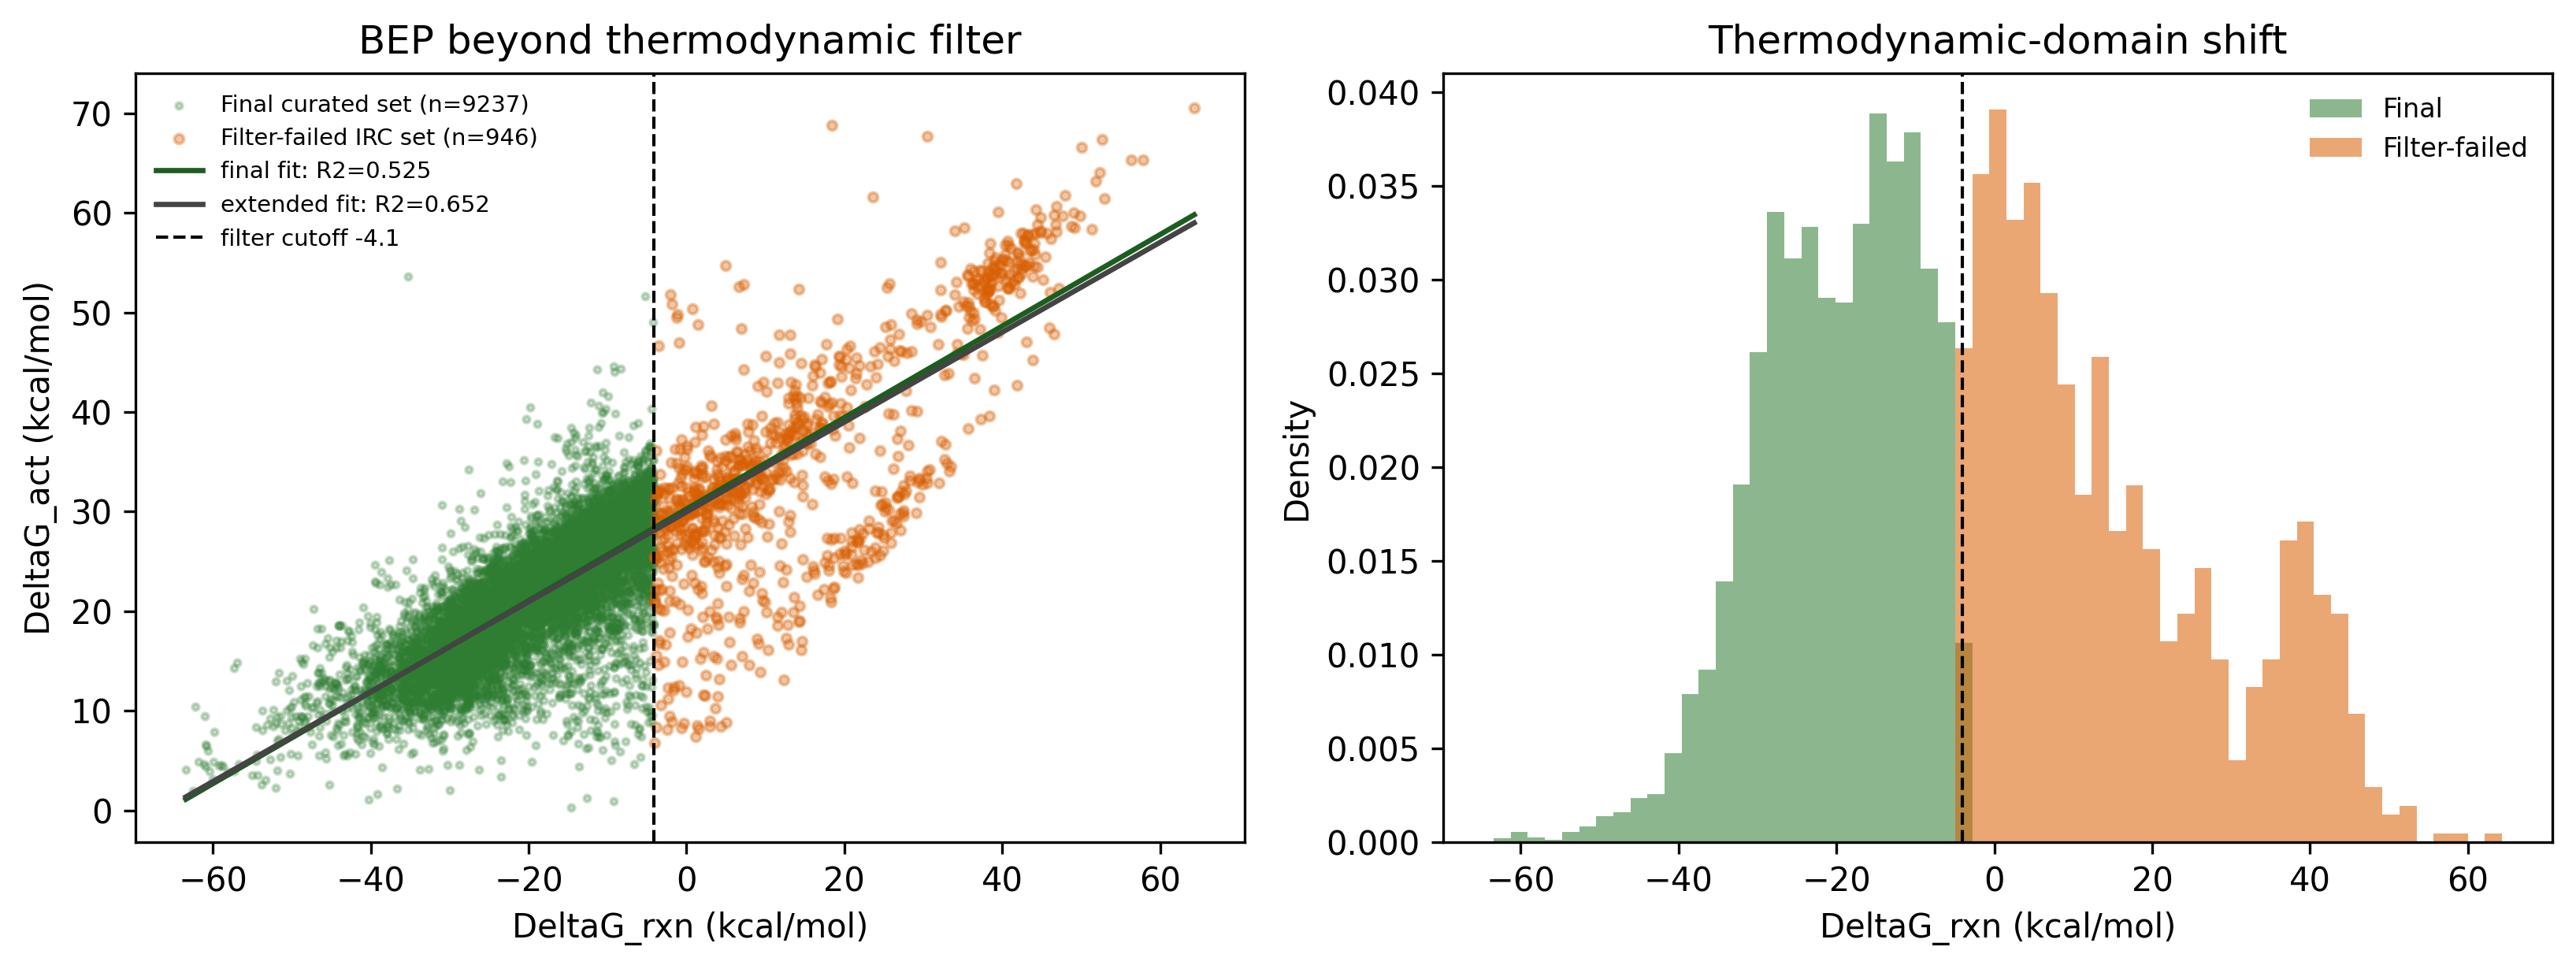

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=300)

ax = axes[0]
ax.scatter(
    final_df["deltaG(kcal/mol)"], final_df["deltaGa(kcal/mol)"],
    s=4, alpha=0.25, c="#2e7d32", label="Final curated set (n=9237)",
)
ax.scatter(
    extended_df["deltaG(kcal/mol)"], extended_df["deltaGa(kcal/mol)"],
    s=8, alpha=0.35, c="#d95f02", label=f"Filter-failed IRC set (n={len(extended_df)})",
)

for data, color, label in [
    (final_df, "#1b5e20", "final fit"),
    (combined_df, "#444444", "extended fit"),
]:
    x = data["deltaG(kcal/mol)"].to_numpy().reshape(-1, 1)
    y = data["deltaGa(kcal/mol)"].to_numpy()
    model = LinearRegression().fit(x, y)
    xs = np.linspace(combined_df["deltaG(kcal/mol)"].min(), combined_df["deltaG(kcal/mol)"].max(), 200)
    ax.plot(xs, model.predict(xs.reshape(-1, 1)), color=color, lw=1.6, label=f"{label}: R2={r2_score(y, model.predict(x)):.3f}")

ax.axvline(-4.1, color="black", ls="--", lw=1, label="filter cutoff -4.1")
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("DeltaG_act (kcal/mol)")
ax.set_title("BEP beyond thermodynamic filter")
ax.legend(frameon=False, fontsize=7, loc="upper left")

ax = axes[1]
bins = np.linspace(combined_df["deltaG(kcal/mol)"].min(), combined_df["deltaG(kcal/mol)"].max(), 60)
ax.hist(final_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#2e7d32", label="Final")
ax.hist(extended_df["deltaG(kcal/mol)"], bins=bins, density=True, alpha=0.55, color="#d95f02", label="Filter-failed")
ax.axvline(-4.1, color="black", ls="--", lw=1)
ax.set_xlabel("DeltaG_rxn (kcal/mol)")
ax.set_ylabel("Density")
ax.set_title("Thermodynamic-domain shift")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_ThermoFilter_BEP_Extension.png", bbox_inches="tight")
plt.show()




## 4. Descriptor Coverage

The original descriptor maps are reused without recomputing DFT descriptors. This is only valid if every filter-failed reaction has both its LB-B descriptor and its chloride/radical descriptor available.




In [20]:
DUPLICATE_CL_IDS = [
    624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
    637, 638, 639, 640, 642, 644, 645, 652, 653, 654, 655, 656, 657,
    658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670,
    671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683,
    684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696,
    697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709,
    710, 711, 713, 714, 716, 717, 718, 719, 720, 721, 722,
]

with open(DESCRIPTOR_DIR / "BNdes_new2.pkl", "rb") as handle:
    bn_map = pickle.load(handle)
with open(DESCRIPTOR_DIR / "Cldes_new2.pkl", "rb") as handle:
    cl_map = pickle.load(handle)


def descriptor_keys(df):
    keys = df[["B_Index", "N_Index", "Cl_Index", "Cl_Atomid"]].copy()
    keys["bn_key"] = [f"B_{int(b):05d}_Nu_{int(n):05d}" for b, n in zip(keys["B_Index"], keys["N_Index"])]
    keys["cl_key"] = [
        f"Cl_{int(cl):05d}_Claid_{int(atom):05d}" if int(cl) in DUPLICATE_CL_IDS else f"Cl_{int(cl):05d}"
        for cl, atom in zip(keys["Cl_Index"], keys["Cl_Atomid"])
    ]
    return keys

coverage = descriptor_keys(extended_df)
coverage["bn_descriptor_available"] = coverage["bn_key"].isin(bn_map)
coverage["cl_descriptor_available"] = coverage["cl_key"].isin(cl_map)
coverage["all_descriptors_available"] = coverage["bn_descriptor_available"] & coverage["cl_descriptor_available"]

coverage_summary = coverage[["bn_descriptor_available", "cl_descriptor_available", "all_descriptors_available"]].sum().to_frame("covered")
coverage_summary["total"] = len(coverage)
coverage_summary["fraction"] = coverage_summary["covered"] / coverage_summary["total"]
coverage_summary


,covered,total,fraction
bn_descriptor_available,946,946,1.0
cl_descriptor_available,946,946,1.0
all_descriptors_available,946,946,1.0


In [21]:
FEATURE_NAMES = [
    "DeltaG_rxn",
    "LB-B spin_B", "LB-B qH_B", "LB-B distance", "LB-B HOMO/SOMO",
    "LB-B-Cl qH_B", "LB-B-Cl qH_Cl", "LB-B-Cl B-Cl distance", "LB-B-Cl LUMO", "LB-B-Cl buried_volume_B",
    "C-Cl qH_Cl", "C-Cl qH_C", "C-Cl distance", "C-Cl LUMO", "C-Cl buried_volume_C",
    "C radical spin_C", "C radical qH_C", "C radical HOMO/SOMO",
]


def dataframe_to_descriptors_local(df, bn_descriptor_map, cl_descriptor_map):
    xs = []
    missing = []
    for idx, row in df.iterrows():
        b_index = int(row["B_Index"])
        n_index = int(row["N_Index"])
        cl_index = int(row["Cl_Index"])
        cl_atomid = int(row["Cl_Atomid"])
        bn_key = f"B_{b_index:05d}_Nu_{n_index:05d}"
        cl_key = f"Cl_{cl_index:05d}_Claid_{cl_atomid:05d}" if cl_index in DUPLICATE_CL_IDS else f"Cl_{cl_index:05d}"
        if bn_key not in bn_descriptor_map or cl_key not in cl_descriptor_map:
            missing.append((idx, bn_key, cl_key))
            continue
        des_a = bn_descriptor_map[bn_key]
        des_b = cl_descriptor_map[cl_key]
        delta_g = [(des_a[0] + des_b[0]) * HARTREE_TO_KCAL]
        xs.append(delta_g + des_a[1:] + des_b[1:])
    if missing:
        raise KeyError(f"Missing descriptors for {len(missing)} rows; first entries: {missing[:5]}")
    return np.asarray(xs, dtype=float)

X_final = dataframe_to_descriptors_local(final_df, bn_map, cl_map)
y_final = final_df["deltaGa(kcal/mol)"].to_numpy(dtype=float)
X_ext = dataframe_to_descriptors_local(extended_df, bn_map, cl_map)
y_ext = extended_df["deltaGa(kcal/mol)"].to_numpy(dtype=float)
X_aug = np.vstack([X_final, X_ext])
y_aug = np.concatenate([y_final, y_ext])

print("X_final", X_final.shape, "y_final", y_final.shape)
print("X_ext", X_ext.shape, "y_ext", y_ext.shape)
print("X_aug", X_aug.shape, "y_aug", y_aug.shape)
print("Descriptor DeltaG vs result DeltaG, extended set:")
print(pd.Series(X_ext[:, 0] - extended_df["deltaG(kcal/mol)"].to_numpy()).describe())




X_final (9237, 18) y_final (9237,)
X_ext (946, 18) y_ext (946,)
X_aug (10183, 18) y_aug (10183,)
Descriptor DeltaG vs result DeltaG, extended set:
count    9.460000e+02
mean    -3.335169e-05
std      2.374631e-04
min     -8.157500e-04
25%     -2.353125e-04
50%     -1.900391e-11
75%      1.255000e-04
max      6.902500e-04
dtype: float64


## 5. ML Impact Analysis

Two questions are tested:

1. If the 1076 filter-failed reactions are added, do validation metrics and feature importance change?
2. If the original model is trained only on the final 9237 rows, how well does it extrapolate to the thermodynamically unfavorable 1076 rows?

The notebook uses CatBoost when available to mirror `5_Modeling.ipynb`. If CatBoost is not installed, it falls back to RandomForest so the analysis remains runnable.




In [22]:
try:
    from catboost import CatBoostRegressor
    MODEL_KIND = "CatBoost"
except ImportError:
    CatBoostRegressor = None
    MODEL_KIND = "RandomForestFallback"


def make_model(seed=RANDOM_STATE):
    if MODEL_KIND == "CatBoost":
        return CatBoostRegressor(
            iterations=CATBOOST_ITERATIONS,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=seed,
        )
    return RandomForestRegressor(
        n_estimators=RF_TREES,
        random_state=seed,
        n_jobs=-1,
        min_samples_leaf=1,
    )


def evaluate_predictions(label, y_true, y_pred):
    return {
        "label": label,
        "n": len(y_true),
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MSE": mean_squared_error(y_true, y_pred),
    }


def cross_val_metrics(label, X, y, n_splits=N_SPLITS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    pred = np.zeros_like(y, dtype=float)
    fold_rows = []
    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        model = make_model(seed=RANDOM_STATE)
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        pred[test_idx] = y_pred
        fold_rows.append(evaluate_predictions(f"{label}_fold_{fold}", y[test_idx], y_pred))
    overall = evaluate_predictions(label, y, pred)
    return overall, pd.DataFrame(fold_rows), pred

print("Model kind:", MODEL_KIND)
print("CatBoost iterations:", CATBOOST_ITERATIONS if MODEL_KIND == "CatBoost" else "N/A")
print("RF trees:", RF_TREES if MODEL_KIND != "CatBoost" else "N/A")




Model kind: CatBoost
CatBoost iterations: 1000
RF trees: N/A


In [23]:
final_cv, final_fold_metrics, final_cv_pred = cross_val_metrics("final_cv", X_final, y_final)
aug_cv, aug_fold_metrics, aug_cv_pred = cross_val_metrics("augmented_cv", X_aug, y_aug)

original_model = make_model(seed=RANDOM_STATE)
original_model.fit(X_final, y_final)
y_ext_pred_from_final = original_model.predict(X_ext)
ext_test_metrics = evaluate_predictions("train_final_test_filter_failed", y_ext, y_ext_pred_from_final)

ml_summary = pd.DataFrame([final_cv, aug_cv, ext_test_metrics])
ml_summary.to_csv(OUTPUT_DIR / "ml_summary.csv", index=False)
ml_summary


,label,n,R2,MAE,RMSE,MSE
0,final_cv,9237,0.863935,1.705823,2.340647,5.478628
1,augmented_cv,10183,0.904136,1.810061,2.553702,6.521395
2,train_final_test_filter_failed,946,-0.396314,10.521515,14.166964,200.702870


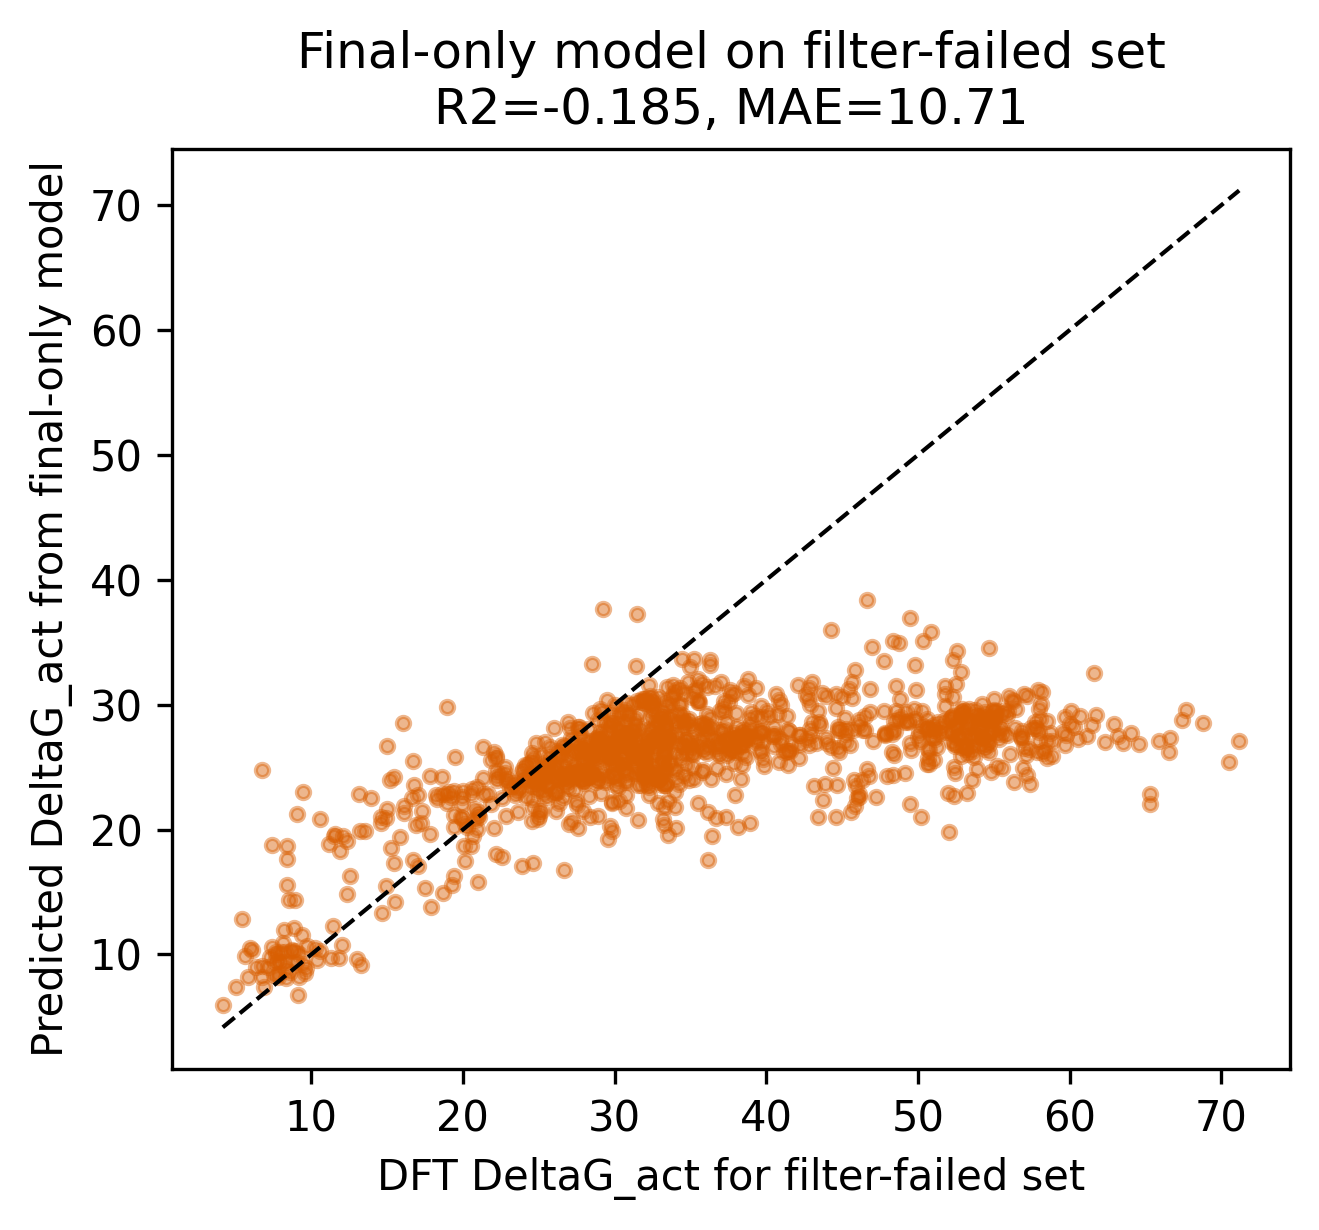

,B_Index,N_Index,Cl_Index,deltaG(kcal/mol),deltaGa(kcal/mol),pred_from_final_model,residual_pred_minus_dft
983,436,302,486,64.318185,70.519479,25.380088,-45.139391
984,436,306,492,78.037469,71.188620,27.120974,-44.067646
982,436,302,479,57.874074,65.291231,22.041058,-43.250173
241,399,184,492,56.333436,65.301402,22.885146,-42.416257
981,436,296,453,50.040239,66.557055,26.218509,-40.338546
752,423,160,479,18.380416,68.811129,28.520465,-40.290664
294,400,377,492,74.484438,66.599976,27.344562,-39.255414
962,434,377,492,71.716473,65.873312,27.113606,-38.759706
199,395,333,618,52.637085,67.416159,28.818029,-38.598130
1049,441,302,485,30.544566,67.696200,29.541493,-38.154706


In [ ]:
prediction_df = extended_df[["B_Index", "N_Index", "Cl_Index", "deltaG(kcal/mol)", "deltaGa(kcal/mol)"]].copy()
prediction_df["pred_from_final_model"] = y_ext_pred_from_final
prediction_df["residual_pred_minus_dft"] = prediction_df["pred_from_final_model"] - prediction_df["deltaGa(kcal/mol)"]
fig, ax = plt.subplots(figsize=(4.5, 4.2), dpi=300)
ax.scatter(y_ext, y_ext_pred_from_final, s=10, alpha=0.45, color="#d95f02")
lo = min(y_ext.min(), y_ext_pred_from_final.min())
hi = max(y_ext.max(), y_ext_pred_from_final.max())
ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
ax.set_xlabel("DFT DeltaG_act for filter-failed set")
ax.set_ylabel("Predicted DeltaG_act from final-only model")
ax.set_title(f"Final-only model on filter-failed set\nR2={ext_test_metrics['R2']:.3f}, MAE={ext_test_metrics['MAE']:.2f}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_ThermoFilter_ML_Prediction.png", bbox_inches="tight")
plt.show()

prediction_df.sort_values("residual_pred_minus_dft", key=np.abs, ascending=False).head(10)


In [ ]:
def model_feature_importance(model, X=None, y=None):
    if MODEL_KIND == "CatBoost":
        values = np.asarray(model.get_feature_importance(), dtype=float)
    elif hasattr(model, "feature_importances_"):
        values = np.asarray(model.feature_importances_, dtype=float)
    else:
        result = permutation_importance(model, X, y, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
        values = result.importances_mean
    total = np.sum(np.abs(values))
    if total > 0:
        values = values / total * 100
    return values

final_importance_model = make_model(seed=RANDOM_STATE)
final_importance_model.fit(X_final, y_final)
aug_importance_model = make_model(seed=RANDOM_STATE)
aug_importance_model.fit(X_aug, y_aug)

importance_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance_final_model": model_feature_importance(final_importance_model, X_final, y_final),
    "importance_augmented_model": model_feature_importance(aug_importance_model, X_aug, y_aug),
})
importance_df["importance_change_aug_minus_final"] = importance_df["importance_augmented_model"] - importance_df["importance_final_model"]
importance_df = importance_df.sort_values("importance_augmented_model", ascending=False)
importance_df.head(12)


,feature,importance_final_model,importance_augmented_model,importance_change_aug_minus_final
0,DeltaG_rxn,33.215646,47.514637,14.298991
12,C-Cl distance,10.705924,8.320554,-2.385370
8,LB-B-Cl LUMO,8.043248,7.203986,-0.839262
10,C-Cl qH_Cl,6.360933,6.951879,0.590946
1,LB-B spin_B,9.591206,5.841138,-3.750068
17,C radical HOMO/SOMO,6.329826,5.484061,-0.845765
4,LB-B HOMO/SOMO,6.505650,4.713471,-1.792179
3,LB-B distance,4.823625,3.187074,-1.636551
15,C radical spin_C,2.732151,1.735145,-0.997006
7,LB-B-Cl B-Cl distance,2.673071,1.681344,-0.991727


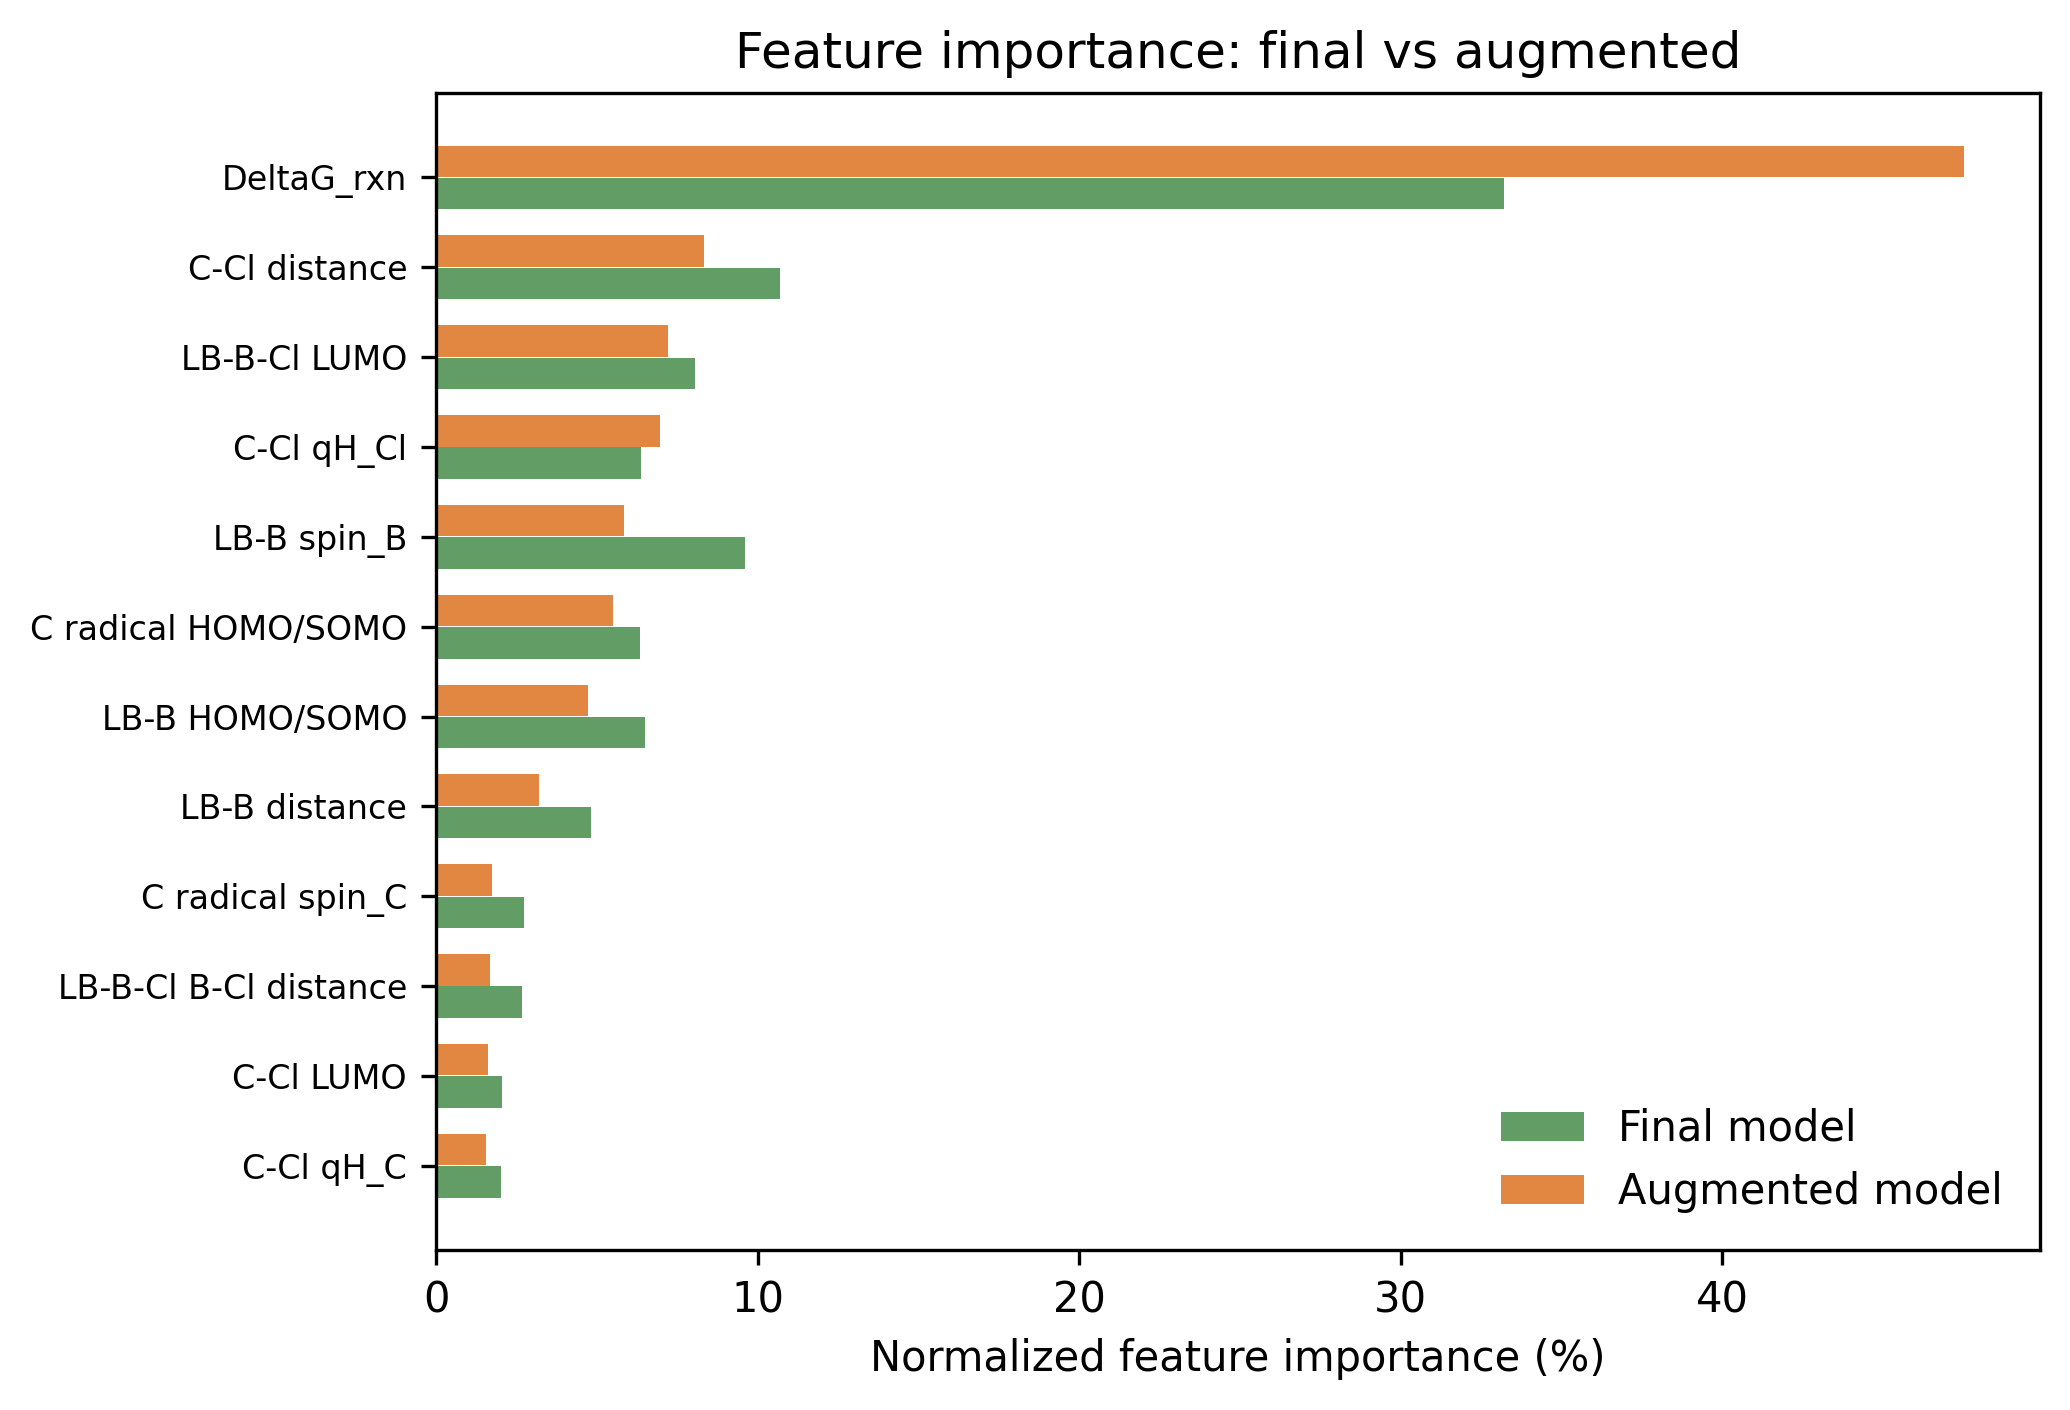

In [ ]:
plot_df = importance_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.8), dpi=300)
ypos = np.arange(len(plot_df))
ax.barh(ypos - 0.18, plot_df["importance_final_model"], height=0.35, color="#2e7d32", alpha=0.75, label="Final model")
ax.barh(ypos + 0.18, plot_df["importance_augmented_model"], height=0.35, color="#d95f02", alpha=0.75, label="Augmented model")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["feature"], fontsize=8)
ax.set_xlabel("Normalized feature importance (%)")
ax.set_title("Feature importance: final vs augmented")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Revision_ThermoFilter_Feature_Importance_Compare.png", bbox_inches="tight")
plt.show()




## 6. Reactant Coverage Of The Filter-Failed Set

This section checks whether the 1076 thermodynamically unfavorable reactions are broad or concentrated in a small number of reactants.




In [ ]:
def lb_type_from_index(n_index):
    n_index = int(n_index)
    if 69 <= n_index < 144:
        return "Phosphine"
    if 144 <= n_index < 234:
        return "NHC"
    if (0 <= n_index < 69) or (234 <= n_index < 388):
        return "Amine/Aryl N"
    return "Other"


def cl_type_from_smiles(smiles):
    n_cl = str(smiles).count("Cl")
    if n_cl >= 4:
        return "CCl4"
    if n_cl == 3:
        return "CCl3"
    if n_cl == 2:
        return "CCl2"
    return "CCl"

coverage_df = extended_df.copy()
coverage_df["LB_type"] = coverage_df["N_Index"].map(lb_type_from_index)
coverage_df["Cl_type_simple"] = coverage_df["Cl_smiles"].map(cl_type_from_smiles)

final_components = {
    "B_Index": set(final_df["B_Index"].astype(int)),
    "N_Index": set(final_df["N_Index"].astype(int)),
    "Cl_Index": set(final_df["Cl_Index"].astype(int)),
}
ext_components = {
    "B_Index": set(coverage_df["B_Index"].astype(int)),
    "N_Index": set(coverage_df["N_Index"].astype(int)),
    "Cl_Index": set(coverage_df["Cl_Index"].astype(int)),
}

component_summary = []
for axis in ["B_Index", "N_Index", "Cl_Index"]:
    component_summary.append({
        "axis": axis,
        "extended_unique": len(ext_components[axis]),
        "final_unique": len(final_components[axis]),
        "extended_in_final": len(ext_components[axis] & final_components[axis]),
        "extended_not_in_final": len(ext_components[axis] - final_components[axis]),
        "fraction_of_final_component_space": len(ext_components[axis] & final_components[axis]) / len(final_components[axis]),
    })
component_summary = pd.DataFrame(component_summary)
component_summary


,axis,extended_unique,final_unique,extended_in_final,extended_not_in_final,fraction_of_final_component_space
0,B_Index,55,55,55,0,1.000000
1,N_Index,142,384,142,0,0.369792
2,Cl_Index,120,178,119,1,0.668539


In [ ]:
coverage_tables = {
    "LB_type": coverage_df["LB_type"].value_counts().rename_axis("LB_type").reset_index(name="count"),
    "Cl_type_simple": coverage_df["Cl_type_simple"].value_counts().rename_axis("Cl_type_simple").reset_index(name="count"),
    "Top_B_Index": coverage_df["B_Index"].value_counts().head(20).rename_axis("B_Index").reset_index(name="count"),
    "Top_N_Index": coverage_df["N_Index"].value_counts().head(20).rename_axis("N_Index").reset_index(name="count"),
    "Top_Cl_Index": coverage_df["Cl_Index"].value_counts().head(20).rename_axis("Cl_Index").reset_index(name="count"),
}

for name, table in coverage_tables.items():
    print(f"\n{name}")
    display(table)



LB_type


,LB_type,count
0,Amine/Aryl N,601
1,NHC,256
2,Phosphine,219



Cl_type_simple


,Cl_type_simple,count
0,CCl2,604
1,CCl,414
2,CCl4,30
3,CCl3,28



Top_B_Index


,B_Index,count
0,423,215
1,388,67
2,409,58
3,389,42
4,404,40
5,400,38
6,401,34
7,403,30
8,393,25
9,390,24



Top_N_Index


,N_Index,count
0,160,128
1,377,83
2,306,81
3,143,79
4,333,79
5,141,52
6,302,44
7,292,26
8,74,21
9,296,19



Top_Cl_Index


,Cl_Index,count
0,483,207
1,480,110
2,492,94
3,490,67
4,488,39
5,485,36
6,479,32
7,484,26
8,462,23
9,573,22


## 7. First-Stage LB-B Complexation Filter Check

The extended set intentionally fails the second thermodynamic criterion, `DeltaG_rxn < -4.1 kcal/mol`. Here we check whether these reactions also contain LB-B pairs that fail the first complexation criterion, `DeltaG_comb < -4.1 kcal/mol`, using `Data/csvs/reactants_B_N_full.csv`.

This distinction matters for the response: if the first filter is still satisfied, the extended set isolates the effect of the reaction-free-energy filter rather than mixing in unstable LB-B complexes.


In [ ]:
bn_full = pd.read_csv(CSV_DIR / "reactants_B_N_full.csv")
bn_selected = pd.read_csv(CSV_DIR / "reactants_B_N.csv")
for table in [bn_full, bn_selected, extended_df]:
    for col in ["B_Index", "N_Index"]:
        if col in table.columns:
            table[col] = table[col].astype(int)

# The selected table is the descriptor/database-relevant LB-B complex table and is unique by B/N pair.
selected_complex_check = extended_df.merge(
    bn_selected[["B_Index", "N_Index", "B_smiles", "N_smiles", "N_Atomid", "deltaG_comb(kcal)", "deltaE_comb(kcal)", "Error_reason"]],
    on=["B_Index", "N_Index"],
    how="left",
)
selected_complex_check["selected_passes_LB_B_filter"] = selected_complex_check["deltaG_comb(kcal)"] < -4.1
selected_complex_check["selected_fails_LB_B_filter"] = selected_complex_check["deltaG_comb(kcal)"] >= -4.1

# The full table can contain multiple candidate rows per B/N pair, so aggregate it cautiously.
full_pair_agg = bn_full.groupby(["B_Index", "N_Index"]).agg(
    full_candidate_count=("deltaG_comb(kcal)", "size"),
    full_nonmissing_count=("deltaG_comb(kcal)", lambda s: s.notna().sum()),
    full_min_deltaG_comb=("deltaG_comb(kcal)", "min"),
    full_max_deltaG_comb=("deltaG_comb(kcal)", "max"),
    full_any_fail=("deltaG_comb(kcal)", lambda s: bool((s >= -4.1).any())),
    full_all_fail=("deltaG_comb(kcal)", lambda s: bool(s.notna().all() and (s >= -4.1).all())),
    full_any_pass=("deltaG_comb(kcal)", lambda s: bool((s < -4.1).any())),
).reset_index()

extended_pairs = extended_df[["B_Index", "N_Index"]].drop_duplicates()
full_pair_check = extended_pairs.merge(full_pair_agg, on=["B_Index", "N_Index"], how="left")

complexation_summary = pd.DataFrame([
    {
        "level": "extended rows vs selected reactants_B_N.csv",
        "n": len(selected_complex_check),
        "missing_deltaG_comb": int(selected_complex_check["deltaG_comb(kcal)"].isna().sum()),
        "fails_deltaG_comb_ge_minus_4p1": int(selected_complex_check["selected_fails_LB_B_filter"].sum()),
        "passes_deltaG_comb_lt_minus_4p1": int(selected_complex_check["selected_passes_LB_B_filter"].sum()),
        "min_deltaG_comb": selected_complex_check["deltaG_comb(kcal)"].min(),
        "max_deltaG_comb": selected_complex_check["deltaG_comb(kcal)"].max(),
    },
    {
        "level": "unique B/N pairs vs full reactants_B_N_full.csv",
        "n": len(full_pair_check),
        "missing_deltaG_comb": int(full_pair_check["full_candidate_count"].isna().sum()),
        "fails_deltaG_comb_ge_minus_4p1": int(full_pair_check["full_any_fail"].sum()),
        "passes_deltaG_comb_lt_minus_4p1": int(full_pair_check["full_any_pass"].sum()),
        "min_deltaG_comb": full_pair_check["full_min_deltaG_comb"].min(),
        "max_deltaG_comb": full_pair_check["full_max_deltaG_comb"].max(),
    },
])


complexation_summary


,level,n,missing_deltaG_comb,fails_deltaG_comb_ge_minus_4p1,passes_deltaG_comb_lt_minus_4p1,min_deltaG_comb,max_deltaG_comb
0,extended rows vs selected reactants_B_N.csv,1076,0,0,1076,-92.824075,-4.187873
1,unique B/N pairs vs full reactants_B_N_full.csv,614,0,0,614,-92.824075,-4.187873


In [ ]:
near_cutoff_rows = selected_complex_check.sort_values("deltaG_comb(kcal)", ascending=False).head(20)
near_cutoff_counts = pd.DataFrame({
    "threshold_deltaG_comb_greater_than": [-4.5, -5.0, -6.0, -8.0, -10.0],
    "row_count": [int((selected_complex_check["deltaG_comb(kcal)"] > cutoff).sum()) for cutoff in [-4.5, -5.0, -6.0, -8.0, -10.0]],
})
print(selected_complex_check["deltaG_comb(kcal)"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
display(near_cutoff_counts)
display(near_cutoff_rows[["B_Index", "N_Index", "Cl_Index", "deltaG(kcal/mol)", "deltaGa(kcal/mol)", "deltaG_comb(kcal)"]])


count    1076.000000
mean      -51.769091
std        19.685104
min       -92.824075
1%        -80.160004
5%        -78.014187
25%       -68.054195
50%       -54.644019
75%       -41.455793
95%       -14.068655
99%        -8.126966
max        -4.187873
Name: deltaG_comb(kcal), dtype: float64


,threshold_deltaG_comb_greater_than,row_count
0,-4.5,2
1,-5.0,3
2,-6.0,5
3,-8.0,11
4,-10.0,18


,B_Index,N_Index,Cl_Index,deltaG(kcal/mol),deltaGa(kcal/mol),deltaG_comb(kcal)
264,400,120,492,10.348102,16.137229,-4.187873
266,400,122,492,12.600200,17.329611,-4.442280
964,435,30,492,1.196454,7.417652,-4.743224
267,400,132,492,10.097103,19.934646,-5.465645
259,400,71,492,18.016153,24.559396,-5.673485
182,395,120,492,14.555490,16.110422,-6.211297
262,400,92,492,14.232328,18.956882,-6.529188
975,436,122,492,23.423320,25.992725,-6.567160
974,436,122,477,-3.087928,26.063445,-6.567160
261,400,91,492,11.500820,18.597720,-7.321929


Interpretation for the response:

- None of the retained filter-failed reactions uses an LB-B pair with `DeltaG_comb >= -4.1 kcal/mol` in the selected `reactants_B_N.csv` table.
- The same conclusion holds at the unique B/N-pair level against `reactants_B_N_full.csv`: no matching B/N pair has a full-table candidate above the `-4.1 kcal/mol` complexation cutoff.
- Therefore, the extended set isolates the second thermodynamic filter (`DeltaG_rxn`) rather than mixing in reactions from unstable LB-B complexes.


## Notes For Manuscript/Response Drafting

Expected interpretation:

- The filtered extended set, after excluding `N_Index == 5`, provides a direct stress test for the thermodynamic reaction-free-energy filter. CSV outputs are limited to `bep_summary.csv` and `ml_summary.csv` in `Ignored/revision_thermo_filter_outputs/`.
- Adding these rows preserves and strengthens the global BEP trend (`R2` increases for final + filter-failed), so the BEP relationship is not simply an artifact of the `DeltaG_rxn < -4.1 kcal/mol` cutoff.
- The filter-failed region is higher-barrier and more scattered, so the formal database and ML model should be described as valid primarily in the thermodynamically accessible/exergonic XAT domain.
- Descriptor coverage is sufficient for the retained filter-failed rows because these reactions use LB-B and C-Cl components already present in the released reactant/product descriptor maps.
- The poor `train_final_test_filter_failed` result should be discussed as out-of-domain stress-test behavior. The final-only CatBoost model systematically underpredicts high-barrier filter-failed reactions because its predictions are compressed toward the barrier range represented in the final curated training set; the underprediction becomes especially large as the DFT barrier increases.
